# Project: Credit Classification

This project is divided into Four Parts. The first three belong to the midcourse project, and the last will be completed in the final project.

1. Data Prep & EDA
2. Logistic Regression
3. Imbalanced Data
4. Ensemble Models



## Step 1: Data Prep & EDA


In [26]:
# import pandas
import pandas as pd
df = pd.read_csv('../Data/credit_train_clean.csv')
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [28]:
# check columns and rows
df.shape

(100000, 28)

In [30]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [32]:
# We drop values that we don't use
df.drop(columns=['Name', 'SSN', 'ID', 'Customer_ID'],inplace=True)

In [34]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Explore data by viz to find some insights and relationship betweens features

In [39]:
# import library
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
# We can understand our target would be "Credit_Score", check this target
df['Credit_Score'].value_counts()
# We have 3 objects in here, we should group them to 2 objects

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

<Axes: xlabel='Credit_Score', ylabel='Age'>

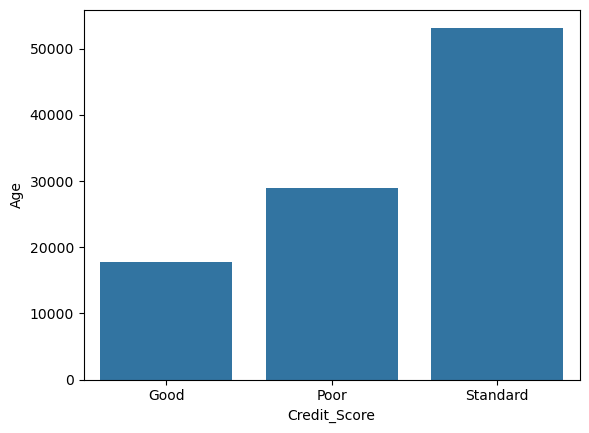

In [47]:
# We have 3 objects in here, we should group them to 2 objects, lets try one viz to see
sns.barplot(data=df.groupby('Credit_Score')['Age'].count().reset_index(),x='Credit_Score',y='Age')

In [51]:
# We will group Good and Standard into 1 group,
df['Credit_Score'] = df['Credit_Score'].map({'Good': 'Good or Standard', 'Standard':'Good or Standard','Poor':'Poor'})

In [53]:
df['Credit_Score'].value_counts()
# We only have 2 objects, it will be easy to apply model to classify and predict

Credit_Score
Good or Standard    71002
Poor                28998
Name: count, dtype: int64

In [65]:
# We already known we have target is "Credit_Score", we will viz all fetaures with target to see what happen
def num_plot(data,target):
    for col in df.select_dtypes(['int','float']):
        sns.boxplot(data=df,x=col,y=target)
        plt.show()

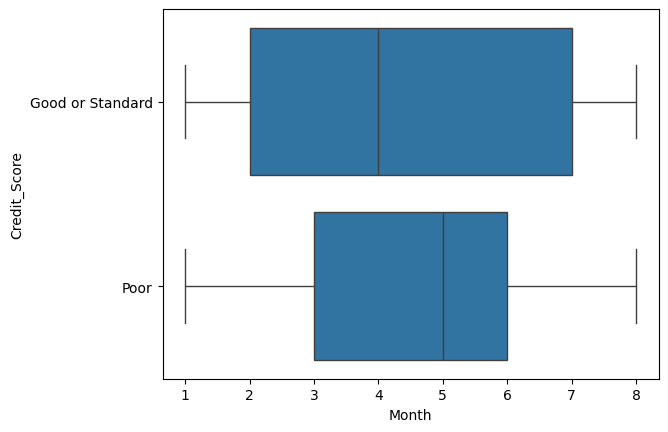

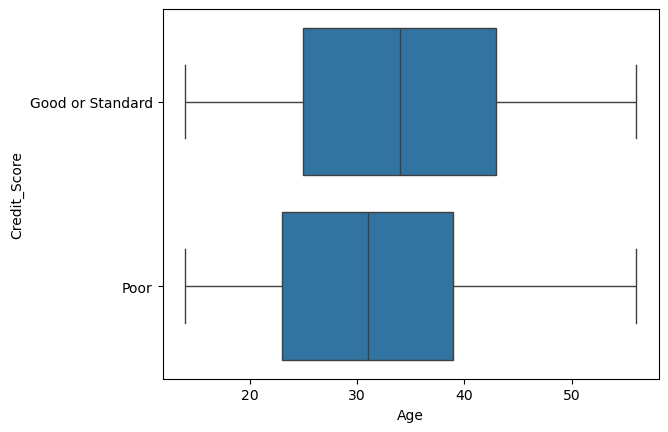

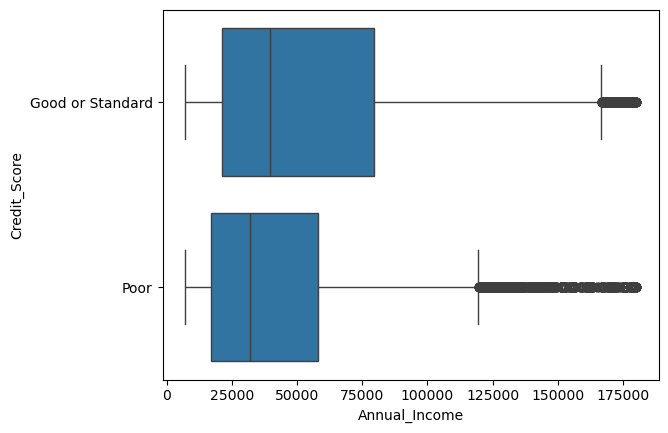

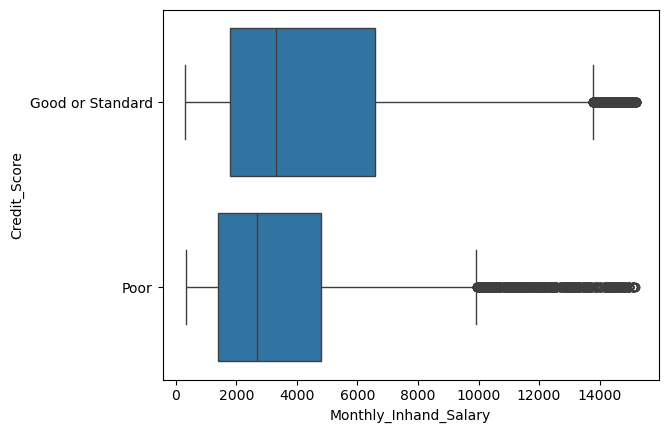

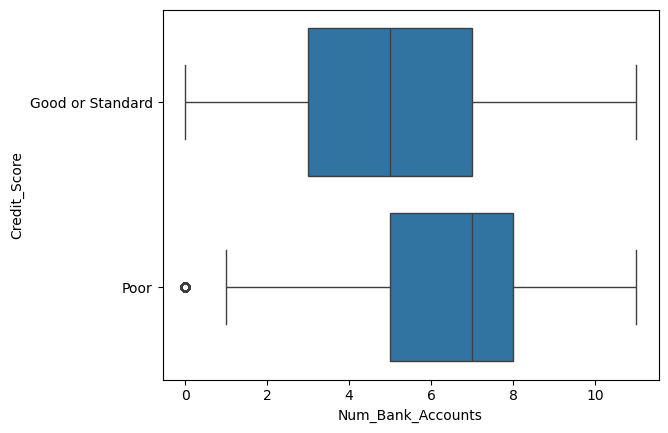

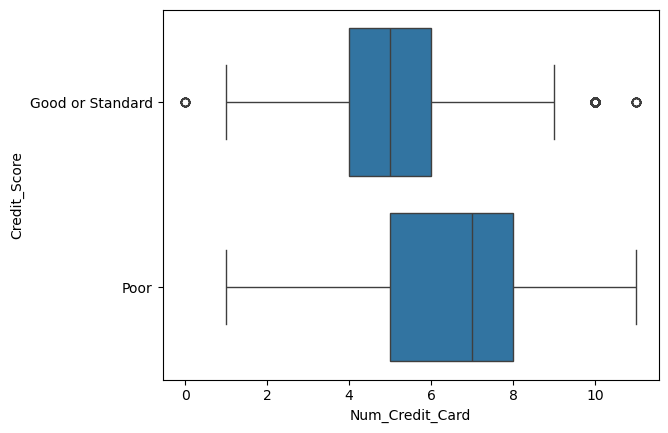

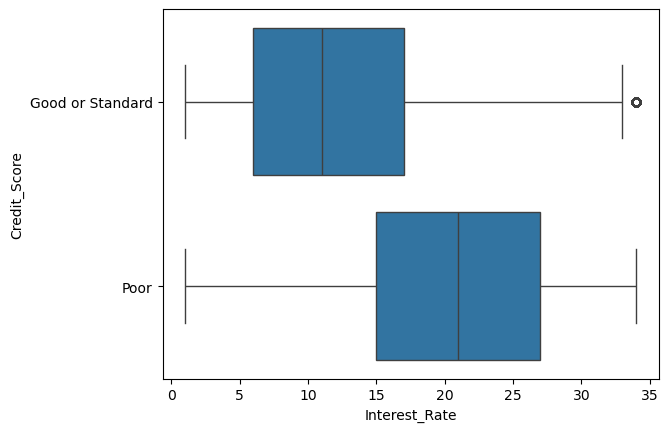

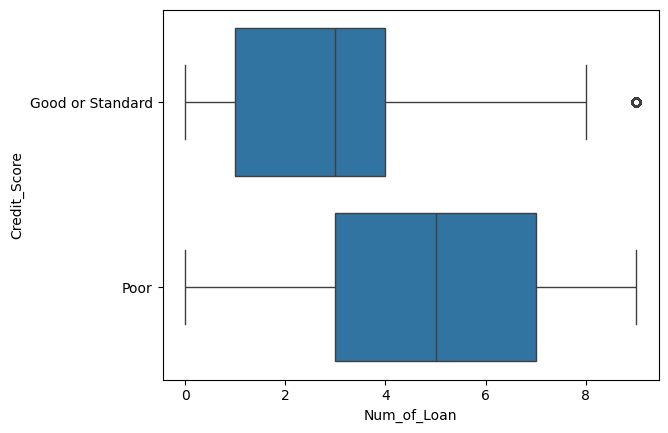

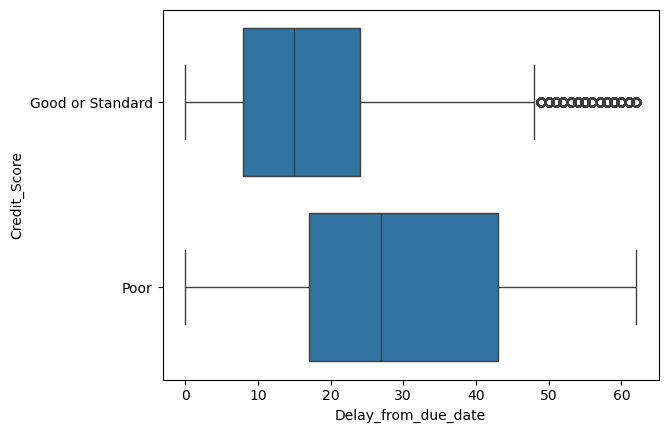

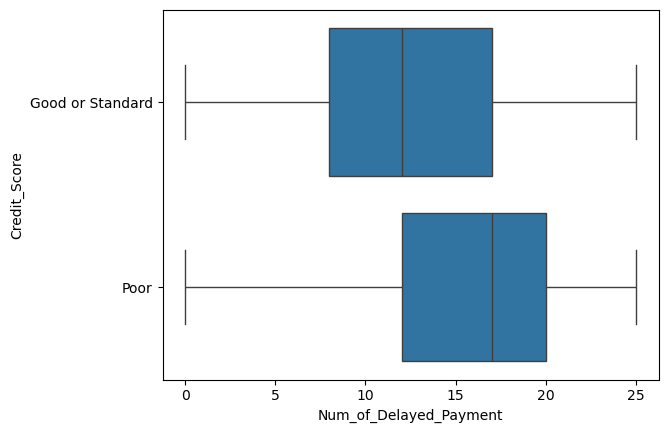

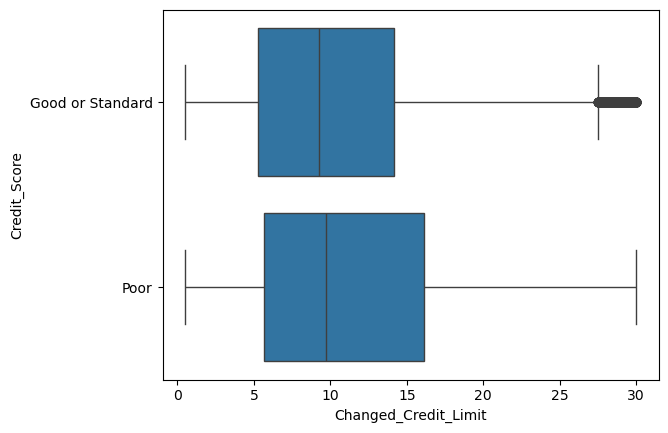

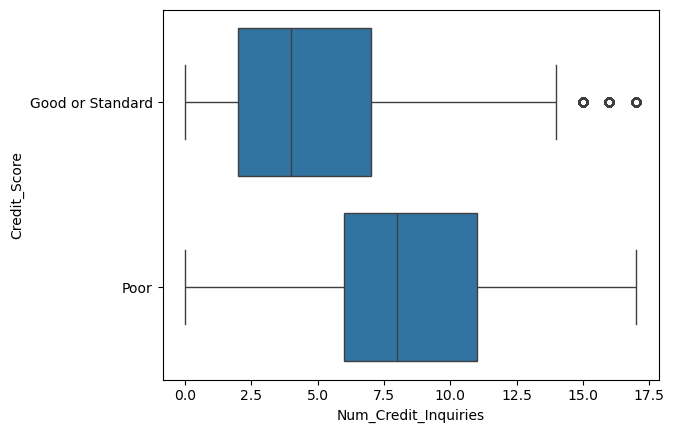

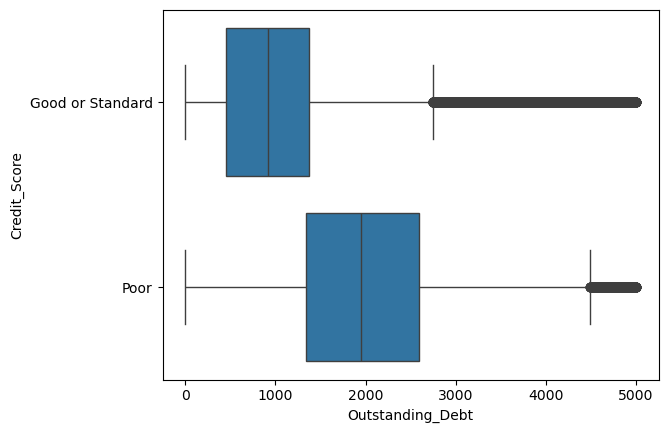

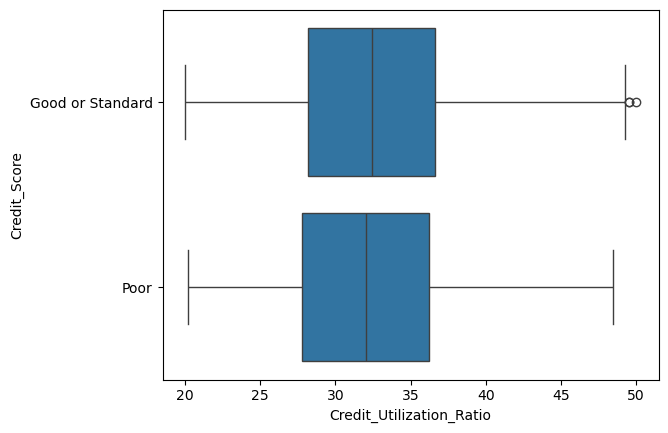

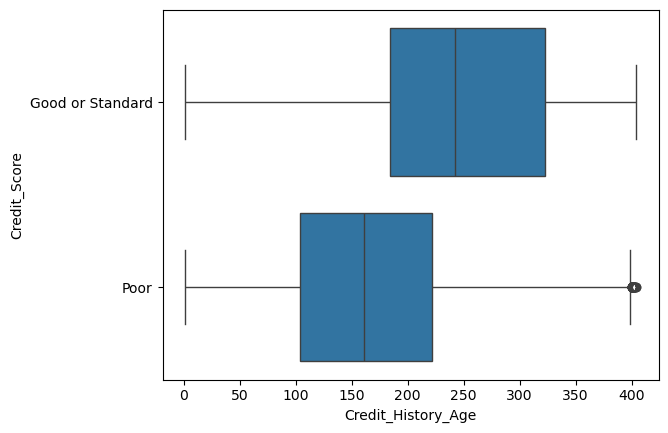

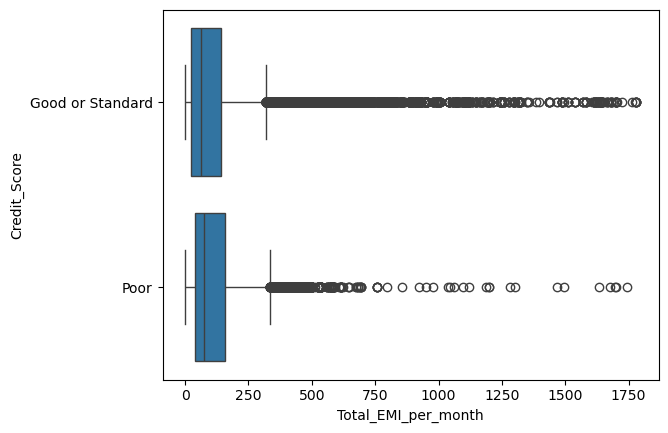

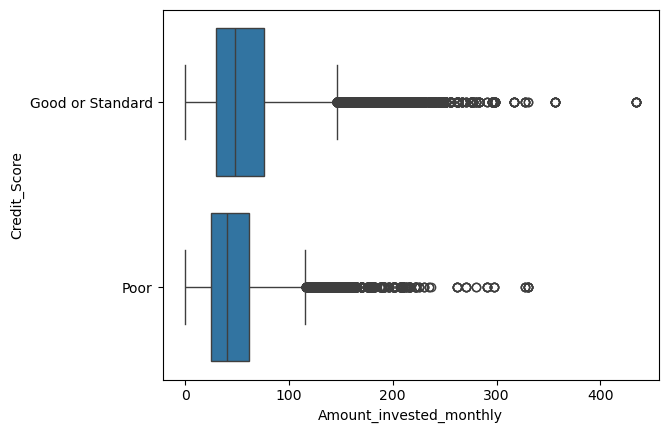

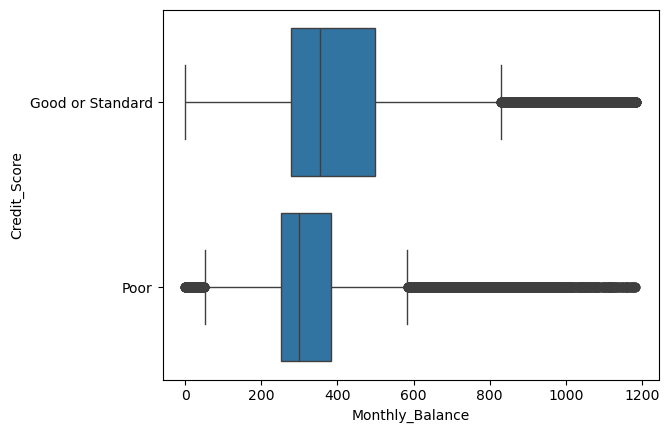

In [67]:
# Lets plot our dataset
num_plot(df,'Credit_Score')

We can see that people with lower income, monthly salaries, and more credit cards or bank accounts tend to have bad credit scores.

In [82]:
# Before viz objective value, we have to tranform our target to numeric
df['target'] = df['Credit_Score'].map({'Good or Standard': 0, 'Poor': 1})

In [97]:
# Let plot it with object feature
def ob_plot(data,target):
    for col in data.select_dtypes(['object']).columns:
        sns.barplot(
            data=(
                data.groupby(col,as_index=False)
                .agg({'target':'mean'})
                .sort_values(by='target',ascending=False)),
                x=col,y=target)
        plt.xticks(rotation=45)
        plt.show()

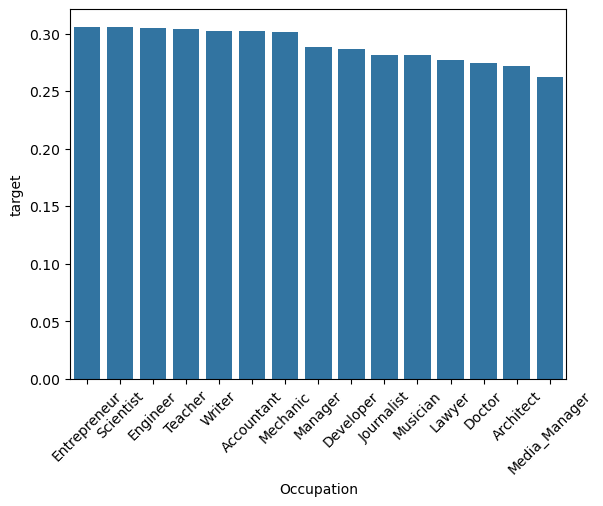

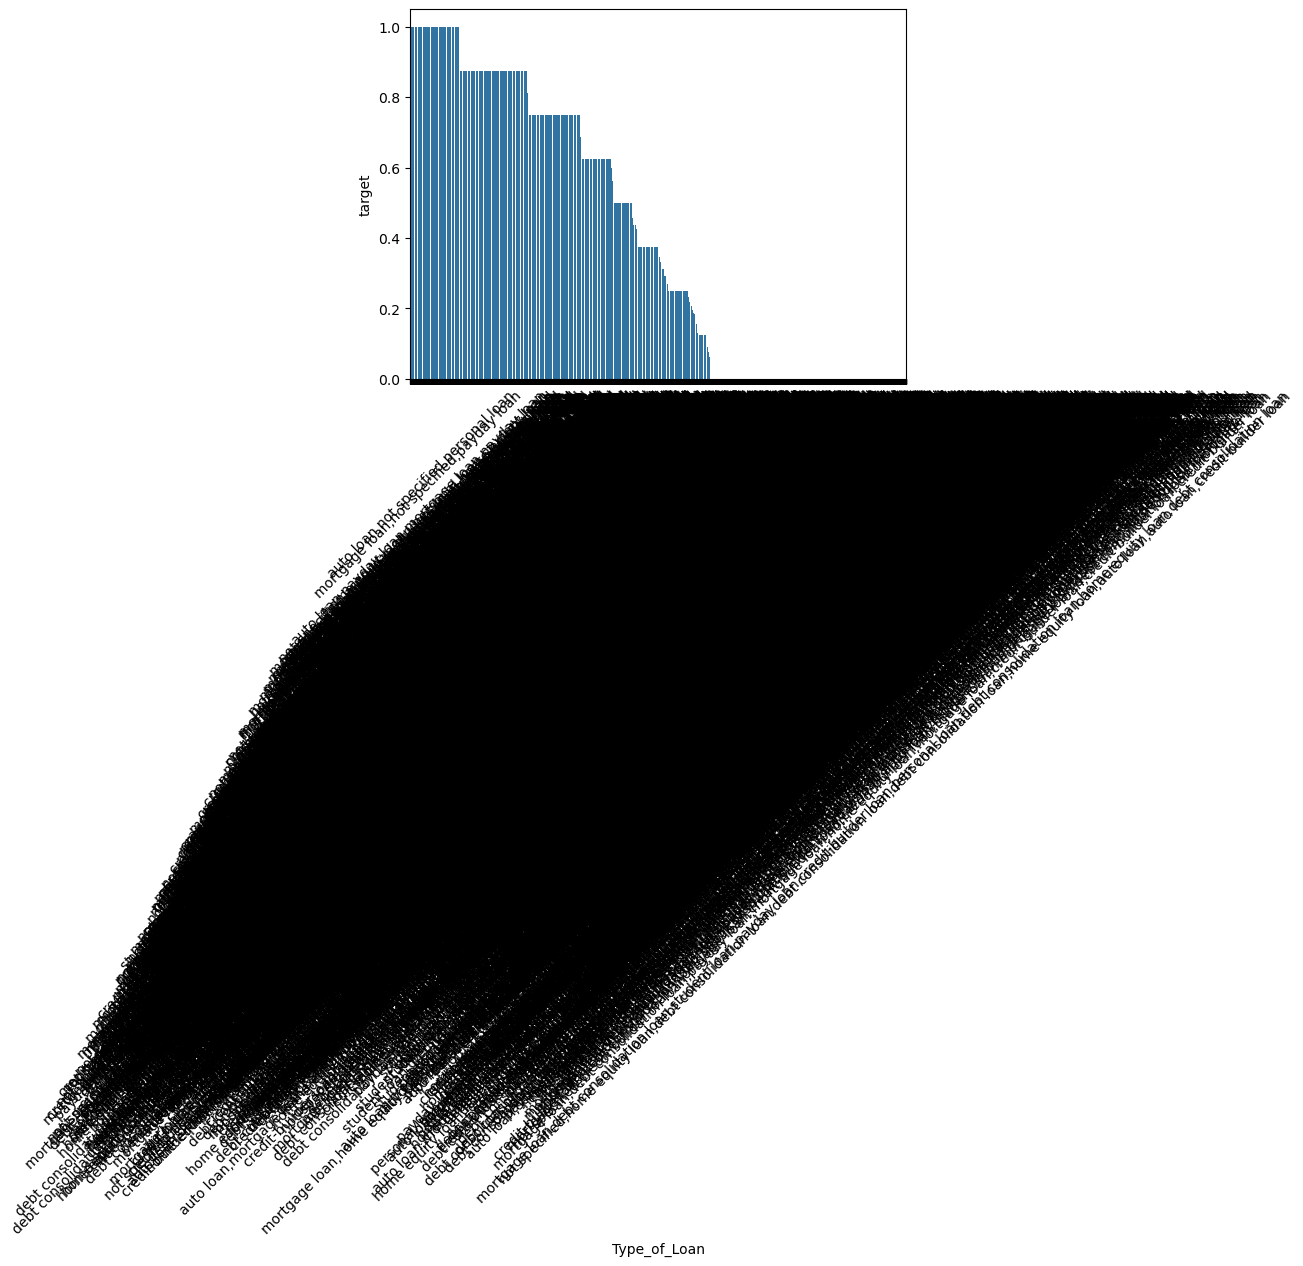

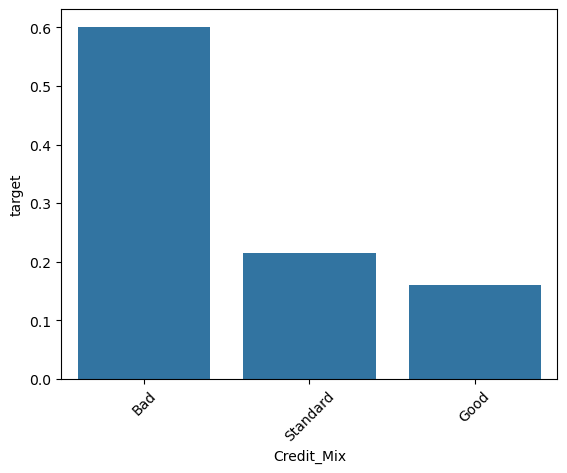

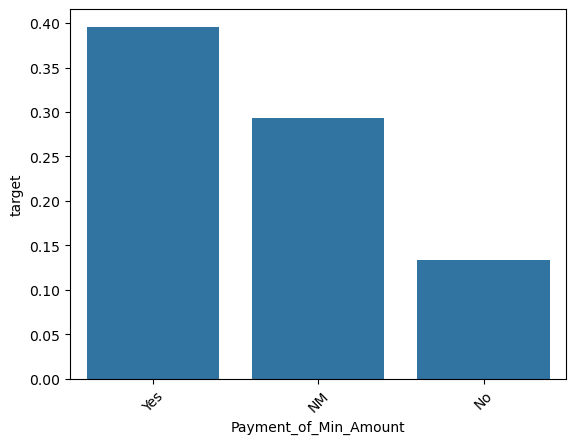

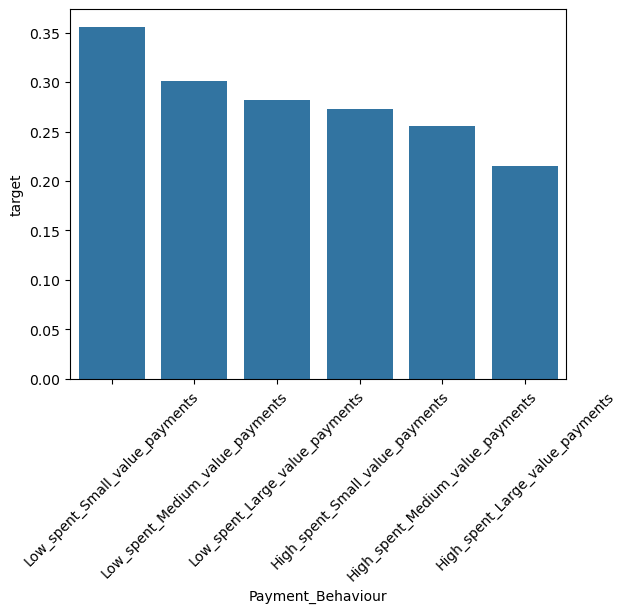

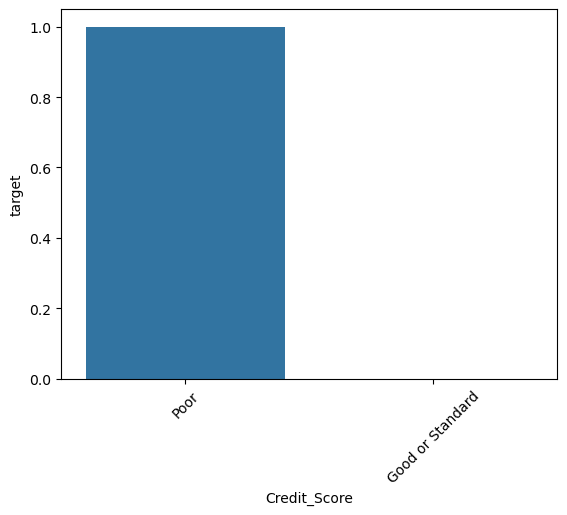

In [98]:
ob_plot(df, 'target')

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  float64
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Num_Credit_Card           100000 non-null  float64
 7   Interest_Rate             100000 non-null  float64
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              100000 non-null  object 
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      100000 non-null  fl

## Step 2: Logistics regression

In [105]:
from sklearn.model_selection import train_test_split

In [113]:
# We split our data for training and testing, we don't take any objective features
features = [
    "Age",
    "Month",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Credit_Utilization_Ratio",
    "Amount_invested_monthly",
    "Interest_Rate",
    "Num_Bank_Accounts",
    "Changed_Credit_Limit",
    "Num_Credit_Card",
    "Credit_History_Age", 
    "Payment_of_Min_Amount", 
    "Monthly_Balance", 
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Mix",
    "Total_EMI_per_month",
]
X = pd.get_dummies(df[features],dtype='int',drop_first=True)
y = df['target']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [146]:
# Scale data before apply Logistics model
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std= std.fit_transform(X_test)

In [121]:
# Apply Logistics regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)

lr = logreg.fit(X_train,y_train)

print(f"Train Accuracy: {lr.score(X_train,y_train)}")
print(f"test Accuracy: {lr.score(X_test,y_test)}")

Train Accuracy: 0.78695
test Accuracy: 0.7846


C:\Users\dinht\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [156]:
# Or we can import accuracy_score to calculate for testing
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
y_pred = lr.predict(X_test)
y_train_pred = lr.predict(X_train)
# Assuming y_pred and Y_test are already defined
test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("train_accuracy: ", train_accuracy)
print("test_accuracy: ", test_accuracy)

train_accuracy:  0.78695
test_accuracy:  0.7846


GridSearchCV is a powerful tool from the scikit-learn library used for tuning hyperparameters of machine learning models to determine the best combination of parameters that provides the most accurate predictive model.

In [139]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
import numpy as np
parameters = {
    "C": np.linspace(.1, 1.1, 11),
    "penalty": ["l1", "l2"],
}

gridsearch = GridSearchCV(LogisticRegression(solver="saga", max_iter=1000), parameters)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'C': 0.2, 'penalty': 'l2'}

In [148]:
# We tune or Logistic regression again with new parameters
logreg = LogisticRegression(max_iter=5000, **gridsearch.best_params_)

lr_tuned = logreg.fit(X_train_std, y_train)

print(f"Train Accuracy: {lr_tuned.score(X_train_std, y_train)}")
print(f"Test Accuracy: {lr_tuned.score(X_test_std, y_test)}")

Train Accuracy: 0.7892875
Test Accuracy: 0.78755


In [172]:
confusion_matrix(y_test, lr_tuned.predict(X_test_std))

array([[12684,  1442],
       [ 2807,  3067]], dtype=int64)

In [ ]:
# Now out train and test accuracy score look better than before after applying Scaler and Gridsearch

<Axes: >

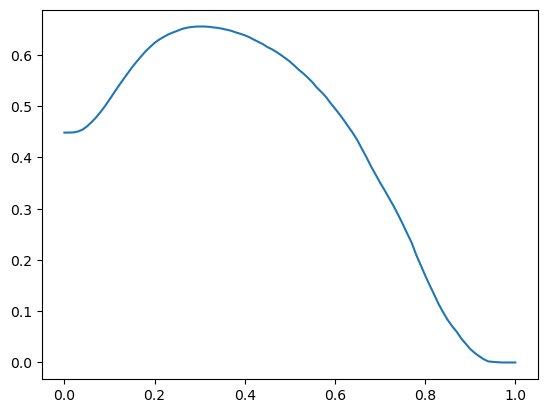

In [150]:
from sklearn.metrics import f1_score

f1 = []

thresholds = np.linspace(0, 1, 101)

for thresh in thresholds:
    y_pred =(lr_tuned.predict_proba(X_train_std)[:,1]>thresh)
    f1.append(f1_score(y_train, y_pred))
    
sns.lineplot(x=thresholds, y=f1)

In [152]:
thresh = thresholds[f1.index(max(f1))]

thresh

0.3

In [158]:
preds = lr_tuned.predict_proba(X_test_std)[:, 1] > thresh

print(f"Accuracy: {accuracy_score(y_test, preds)}")
print(f"Precision: {precision_score(y_test, preds)}")
print(f"Recall: {recall_score(y_test, preds)}")
print(f"F1: {f1_score(y_test, preds)}")

Accuracy: 0.78235
Precision: 0.6115593369517383
Recall: 0.7097378277153558
F1: 0.6570010243479631


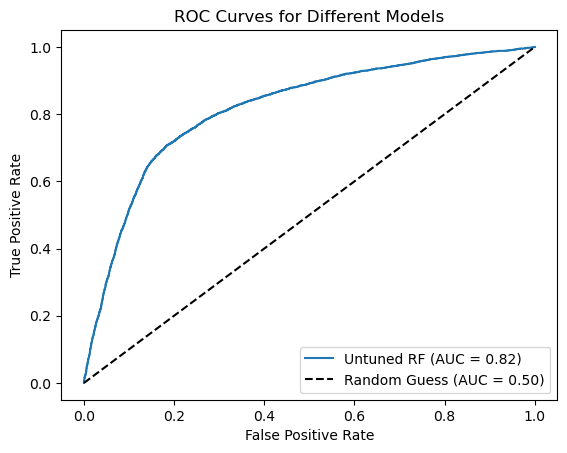

In [164]:
from sklearn.metrics import roc_curve, auc


# Generate ROC AUC for smote model
y_probs = lr_tuned.predict_proba(X_test_std)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label=f'Untuned RF (AUC = {auc_score:.2f})')

# Draw Random Guess
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Modify Formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.show()